# Covariance: Understanding Variable Relationships

## What is Covariance?

**Covariance** is a statistical measure that quantifies how two variables change together. It indicates whether two variables tend to increase or decrease simultaneously, or if they move in opposite directions.

## 🎯 Key Concepts

### **Direction of Relationship:**
- **Positive Covariance**: Variables tend to increase/decrease together
- **Negative Covariance**: One variable increases while the other decreases
- **Zero Covariance**: No linear relationship between variables

### **Interpretation:**
- **High Positive**: Strong positive linear relationship
- **High Negative**: Strong negative linear relationship  
- **Near Zero**: Weak or no linear relationship

## 📐 Mathematical Formulas

### **Population Covariance**
For a complete population of N data points:

```
σ(X,Y) = Σ[(Xi - μX)(Yi - μY)] / N
```

### **Sample Covariance**
For a sample of n data points:

```
s(X,Y) = Σ[(Xi - X̄)(Yi - Ȳ)] / (n-1)
```

**Key Difference**: Sample covariance uses (n-1) for Bessel's correction to provide an unbiased estimator.

In [1]:
# =============================================================================
# 📚 IMPORT REQUIRED LIBRARIES
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")

print("📚 Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

📚 Libraries imported successfully!
NumPy version: 2.3.2
Pandas version: 2.3.2
Matplotlib version: 3.10.6


In [2]:
# =============================================================================
# 📊 DEFINE SAMPLE DATA
# =============================================================================

# Primary example: Study Hours vs Test Scores
study_hours = np.array([2, 4, 6, 8, 10])
test_scores = np.array([60, 70, 80, 90, 95])

print("📊 Primary Dataset: Study Hours vs Test Scores")
print(f"Study Hours (X): {study_hours}")
print(f"Test Scores (Y): {test_scores}")

# Create DataFrame for better visualization
df_primary = pd.DataFrame({
    'Study_Hours': study_hours,
    'Test_Scores': test_scores
})

print("\n📋 Data in table format:")
print(df_primary)

# Additional datasets for different covariance scenarios
np.random.seed(42)

# Positive covariance example
x_pos = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_pos = x_pos * 2 + np.random.normal(0, 1, 10)  # Strong positive relationship

# Negative covariance example
x_neg = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_neg = -x_neg * 1.5 + 20 + np.random.normal(0, 1, 10)  # Negative relationship

# Zero covariance example
x_zero = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_zero = np.random.normal(5, 2, 10)  # No relationship

print("\n🎯 Additional datasets created for different covariance scenarios:")
print("✅ Positive covariance dataset")
print("✅ Negative covariance dataset")
print("✅ Zero covariance dataset")

📊 Primary Dataset: Study Hours vs Test Scores
Study Hours (X): [ 2  4  6  8 10]
Test Scores (Y): [60 70 80 90 95]

📋 Data in table format:
   Study_Hours  Test_Scores
0            2           60
1            4           70
2            6           80
3            8           90
4           10           95

🎯 Additional datasets created for different covariance scenarios:
✅ Positive covariance dataset
✅ Negative covariance dataset
✅ Zero covariance dataset


In [3]:
# =============================================================================
# 🧮 CALCULATE MEANS AND DEVIATIONS
# =============================================================================

def calculate_deviations(x, y, dataset_name="Dataset"):
    """
    Calculate means and deviations for covariance calculation
    """
    # Calculate means
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    # Calculate deviations
    dev_x = x - mean_x
    dev_y = y - mean_y
    
    # Calculate products of deviations
    products = dev_x * dev_y
    
    # Create detailed table
    table_data = pd.DataFrame({
        'Xi': x,
        'Yi': y,
        '(Xi - X̄)': dev_x,
        '(Yi - Ȳ)': dev_y,
        '(Xi - X̄)(Yi - Ȳ)': products
    })
    
    print(f"📊 {dataset_name} - Step-by-Step Calculation")
    print("=" * 50)
    print(f"📈 Step 1: Calculate Means")
    print(f"   Mean of X (X̄): {mean_x:.2f}")
    print(f"   Mean of Y (Ȳ): {mean_y:.2f}")
    
    print(f"\n📋 Step 2: Calculate Deviations and Products")
    print(table_data.round(2))
    
    sum_products = np.sum(products)
    print(f"\n🔢 Sum of products: {sum_products:.2f}")
    
    return mean_x, mean_y, dev_x, dev_y, products, sum_products

# Calculate for primary dataset
mean_x, mean_y, dev_x, dev_y, products, sum_products = calculate_deviations(
    study_hours, test_scores, "Study Hours vs Test Scores"
)

📊 Study Hours vs Test Scores - Step-by-Step Calculation
📈 Step 1: Calculate Means
   Mean of X (X̄): 6.00
   Mean of Y (Ȳ): 79.00

📋 Step 2: Calculate Deviations and Products
   Xi  Yi  (Xi - X̄)  (Yi - Ȳ)  (Xi - X̄)(Yi - Ȳ)
0   2  60       -4.0     -19.0               76.0
1   4  70       -2.0      -9.0               18.0
2   6  80        0.0       1.0                0.0
3   8  90        2.0      11.0               22.0
4  10  95        4.0      16.0               64.0

🔢 Sum of products: 180.00


In [4]:
# =============================================================================
# 📐 IMPLEMENT POPULATION COVARIANCE
# =============================================================================

def population_covariance(x, y, show_steps=True):
    """
    Calculate population covariance with detailed steps
    Formula: σ(X,Y) = Σ[(Xi - μX)(Yi - μY)] / N
    """
    n = len(x)
    
    # Calculate means (population means)
    mu_x = np.mean(x)
    mu_y = np.mean(y)
    
    # Calculate deviations from population means
    deviations_x = x - mu_x
    deviations_y = y - mu_y
    
    # Calculate products of deviations
    products = deviations_x * deviations_y
    
    # Sum of products
    sum_products = np.sum(products)
    
    # Population covariance (divide by N)
    pop_cov = sum_products / n
    
    if show_steps:
        print("🏛️ POPULATION COVARIANCE CALCULATION")
        print("=" * 45)
        print(f"📐 Formula: σ(X,Y) = Σ[(Xi - μX)(Yi - μY)] / N")
        print(f"📊 Data points (N): {n}")
        print(f"📈 Population mean μX: {mu_x:.2f}")
        print(f"📈 Population mean μY: {mu_y:.2f}")
        print(f"🔢 Sum of products: {sum_products:.2f}")
        print(f"🎯 Population Covariance: {sum_products:.2f} / {n} = {pop_cov:.2f}")
    
    return pop_cov

# Calculate population covariance for primary dataset
pop_cov = population_covariance(study_hours, test_scores)

# Verify with NumPy
np_pop_cov = np.cov(study_hours, test_scores, bias=True)[0, 1]
print(f"\n✅ Verification with NumPy: {np_pop_cov:.2f}")
print(f"📊 Match: {'✅ Yes' if abs(pop_cov - np_pop_cov) < 0.01 else '❌ No'}")

🏛️ POPULATION COVARIANCE CALCULATION
📐 Formula: σ(X,Y) = Σ[(Xi - μX)(Yi - μY)] / N
📊 Data points (N): 5
📈 Population mean μX: 6.00
📈 Population mean μY: 79.00
🔢 Sum of products: 180.00
🎯 Population Covariance: 180.00 / 5 = 36.00

✅ Verification with NumPy: 36.00
📊 Match: ✅ Yes


In [ ]:
# =============================================================================
# 📊 IMPLEMENT SAMPLE COVARIANCE
# =============================================================================

def sample_covariance(x, y, show_steps=True):
    """
    Calculate sample covariance with Bessel's correction
    Formula: s(X,Y) = Σ[(Xi - X̄)(Yi - Ȳ)] / (n-1)
    """
    n = len(x)
    
    # Calculate sample means
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    # Calculate deviations from sample means
    deviations_x = x - mean_x
    deviations_y = y - mean_y
    
    # Calculate products of deviations
    products = deviations_x * deviations_y
    
    # Sum of products
    sum_products = np.sum(products)
    
    # Sample covariance (divide by n-1 for Bessel's correction)
    sample_cov = sum_products / (n - 1)
    
    if show_steps:
        print("\n🔬 SAMPLE COVARIANCE CALCULATION")
        print("=" * 40)
        print(f"📐 Formula: s(X,Y) = Σ[(Xi - X̄)(Yi - Ȳ)] / (n-1)")
        print(f"📊 Sample size (n): {n}")
        print(f"📈 Sample mean X̄: {mean_x:.2f}")
        print(f"📈 Sample mean Ȳ: {mean_y:.2f}")
        print(f"🔢 Sum of products: {sum_products:.2f}")
        print(f"⚖️ Bessel's correction: n-1 = {n-1}")
        print(f"🎯 Sample Covariance: {sum_products:.2f} / {n-1} = {sample_cov:.2f}")
        
        print(f"\n💡 Why (n-1)? Bessel's correction provides an unbiased estimator")
        print(f"   of the population covariance when working with sample data.")
    
    return sample_cov

# Calculate sample covariance for primary dataset
samp_cov = sample_covariance(study_hours, test_scores)

# Verify with NumPy
np_samp_cov = np.cov(study_hours, test_scores, bias=False)[0, 1]
print(f"\n✅ Verification with NumPy: {np_samp_cov:.2f}")
print(f"📊 Match: {'✅ Yes' if abs(samp_cov - np_samp_cov) < 0.01 else '❌ No'}")

In [ ]:
# =============================================================================
# 🔍 COMPARE POPULATION VS SAMPLE COVARIANCE
# =============================================================================

def compare_covariances(x, y, dataset_name="Dataset"):
    """
    Compare population and sample covariance calculations
    """
    n = len(x)
    
    # Calculate both types
    pop_cov = population_covariance(x, y, show_steps=False)
    samp_cov = sample_covariance(x, y, show_steps=False)
    
    # Calculate difference and percentage difference
    difference = samp_cov - pop_cov
    pct_difference = (difference / pop_cov) * 100 if pop_cov != 0 else 0
    
    print(f"⚖️ COVARIANCE COMPARISON: {dataset_name}")
    print("=" * 55)
    print(f"📊 Sample size: {n}")
    print(f"🏛️ Population Covariance (÷{n}):   {pop_cov:.4f}")
    print(f"🔬 Sample Covariance (÷{n-1}):      {samp_cov:.4f}")
    print(f"📈 Difference:                   {difference:.4f}")
    print(f"📊 Percentage difference:        {pct_difference:.2f}%")
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Metric': ['Population Covariance', 'Sample Covariance', 'Difference', 'Ratio (Sample/Pop)'],
        'Value': [pop_cov, samp_cov, difference, samp_cov/pop_cov if pop_cov != 0 else 0],
        'Formula': [f'÷{n}', f'÷{n-1}', 'Sample - Pop', 'Sample/Pop']
    })
    
    print(f"\n📋 Detailed Comparison:")
    print(comparison_df.round(4))
    
    return pop_cov, samp_cov, difference

# Compare for primary dataset
pop_cov, samp_cov, diff = compare_covariances(study_hours, test_scores, "Study Hours vs Test Scores")

print(f"\n💭 Key Insights:")
print(f"   • Sample covariance is always larger than population covariance")
print(f"   • The difference decreases as sample size increases")
print(f"   • For large samples (n>30), the difference becomes negligible")
print(f"   • Sample covariance provides an unbiased estimate of population covariance")

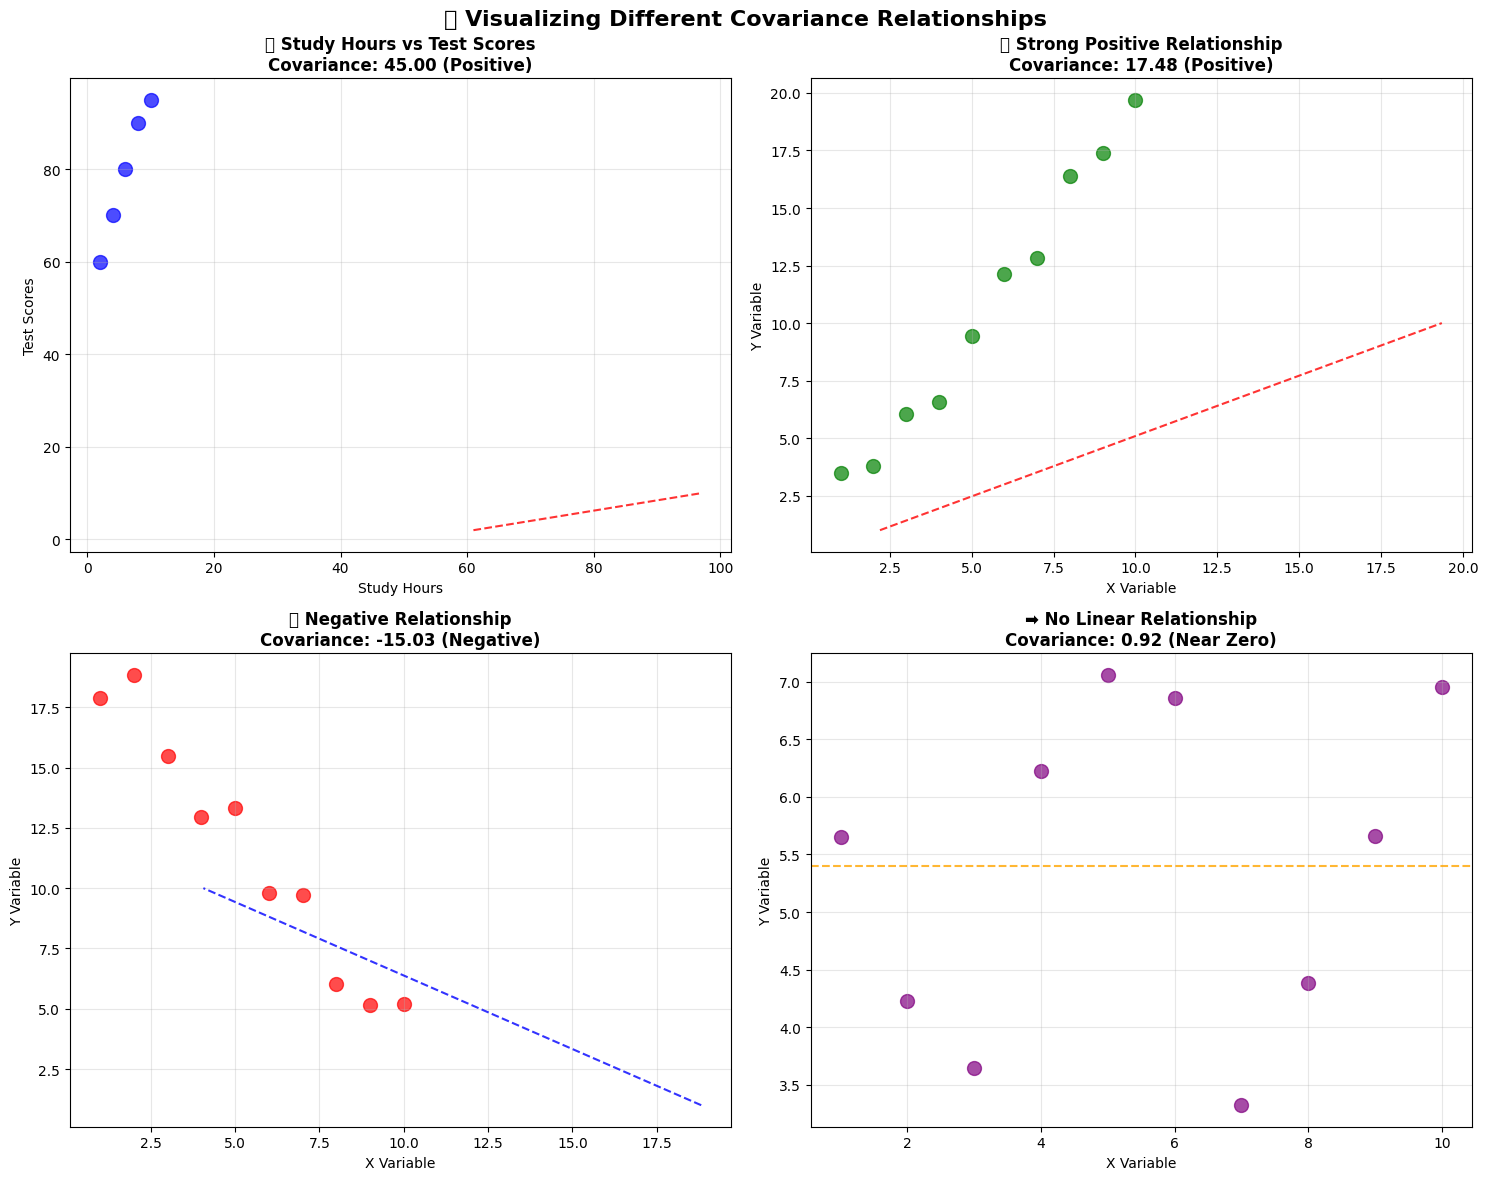

📊 Covariance Summary for All Relationships:
📈 Study Hours vs Test Scores: 45.000 (Strong Positive)
📈 Strong Positive Example:    17.477 (Strong Positive)
📉 Negative Example:           -15.031 (Negative)
➡️ Zero/Weak Example:         0.918 (Near Zero)


In [5]:
# =============================================================================
# 📊 VISUALIZE COVARIANCE RELATIONSHIPS
# =============================================================================

def visualize_covariance_relationships():
    """
    Create visualizations showing different covariance scenarios
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('🔍 Visualizing Different Covariance Relationships', fontsize=16, fontweight='bold')
    
    # 1. Primary dataset (Positive covariance)
    ax1 = axes[0, 0]
    ax1.scatter(study_hours, test_scores, color='blue', s=100, alpha=0.7)
    ax1.plot(np.polyval(np.polyfit(study_hours, test_scores, 1), study_hours), 
             study_hours, 'r--', alpha=0.8)
    cov_primary = np.cov(study_hours, test_scores)[0, 1]
    ax1.set_title(f'📈 Study Hours vs Test Scores\nCovariance: {cov_primary:.2f} (Positive)', fontweight='bold')
    ax1.set_xlabel('Study Hours')
    ax1.set_ylabel('Test Scores')
    ax1.grid(True, alpha=0.3)
    
    # 2. Strong positive covariance
    ax2 = axes[0, 1]
    ax2.scatter(x_pos, y_pos, color='green', s=100, alpha=0.7)
    ax2.plot(np.polyval(np.polyfit(x_pos, y_pos, 1), x_pos), x_pos, 'r--', alpha=0.8)
    cov_pos = np.cov(x_pos, y_pos)[0, 1]
    ax2.set_title(f'📈 Strong Positive Relationship\nCovariance: {cov_pos:.2f} (Positive)', fontweight='bold')
    ax2.set_xlabel('X Variable')
    ax2.set_ylabel('Y Variable')
    ax2.grid(True, alpha=0.3)
    
    # 3. Negative covariance
    ax3 = axes[1, 0]
    ax3.scatter(x_neg, y_neg, color='red', s=100, alpha=0.7)
    ax3.plot(np.polyval(np.polyfit(x_neg, y_neg, 1), x_neg), x_neg, 'b--', alpha=0.8)
    cov_neg = np.cov(x_neg, y_neg)[0, 1]
    ax3.set_title(f'📉 Negative Relationship\nCovariance: {cov_neg:.2f} (Negative)', fontweight='bold')
    ax3.set_xlabel('X Variable')
    ax3.set_ylabel('Y Variable')
    ax3.grid(True, alpha=0.3)
    
    # 4. Zero/weak covariance
    ax4 = axes[1, 1]
    ax4.scatter(x_zero, y_zero, color='purple', s=100, alpha=0.7)
    ax4.axhline(np.mean(y_zero), color='orange', linestyle='--', alpha=0.8)
    cov_zero = np.cov(x_zero, y_zero)[0, 1]
    ax4.set_title(f'➡️ No Linear Relationship\nCovariance: {cov_zero:.2f} (Near Zero)', fontweight='bold')
    ax4.set_xlabel('X Variable')
    ax4.set_ylabel('Y Variable')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("📊 Covariance Summary for All Relationships:")
    print("=" * 50)
    print(f"📈 Study Hours vs Test Scores: {cov_primary:.3f} (Strong Positive)")
    print(f"📈 Strong Positive Example:    {cov_pos:.3f} (Strong Positive)")
    print(f"📉 Negative Example:           {cov_neg:.3f} (Negative)")
    print(f"➡️ Zero/Weak Example:         {cov_zero:.3f} (Near Zero)")
    
    return cov_primary, cov_pos, cov_neg, cov_zero

# Create visualizations
covs = visualize_covariance_relationships()

In [ ]:
# =============================================================================
# 🎯 CALCULATE CORRELATION COEFFICIENT
# =============================================================================

def calculate_correlation_coefficient(x, y, dataset_name="Dataset"):
    """
    Calculate correlation coefficient and compare with covariance
    Formula: r = Cov(X,Y) / (σX × σY)
    """
    # Calculate covariance
    covariance = np.cov(x, y)[0, 1]
    
    # Calculate standard deviations
    std_x = np.std(x, ddof=1)  # Sample standard deviation
    std_y = np.std(y, ddof=1)
    
    # Calculate correlation coefficient
    correlation = covariance / (std_x * std_y)
    
    print(f"🎯 CORRELATION COEFFICIENT: {dataset_name}")
    print("=" * 50)
    print(f"📐 Formula: r = Cov(X,Y) / (σX × σY)")
    print(f"📊 Covariance Cov(X,Y): {covariance:.4f}")
    print(f"📈 Standard deviation σX: {std_x:.4f}")
    print(f"📈 Standard deviation σY: {std_y:.4f}")
    print(f"🎯 Correlation coefficient r: {correlation:.4f}")
    
    # Interpret correlation strength
    if abs(correlation) >= 0.8:
        strength = "Very Strong"
    elif abs(correlation) >= 0.6:
        strength = "Strong"
    elif abs(correlation) >= 0.4:
        strength = "Moderate"
    elif abs(correlation) >= 0.2:
        strength = "Weak"
    else:
        strength = "Very Weak"
    
    direction = "Positive" if correlation > 0 else "Negative" if correlation < 0 else "No"
    
    print(f"\n💡 Interpretation:")
    print(f"   Direction: {direction} relationship")
    print(f"   Strength: {strength} ({abs(correlation):.3f})")
    
    # Verify with NumPy/SciPy
    np_corr = np.corrcoef(x, y)[0, 1]
    scipy_corr, p_value = stats.pearsonr(x, y)
    
    print(f"\n✅ Verification:")
    print(f"   NumPy correlation: {np_corr:.4f}")
    print(f"   SciPy correlation: {scipy_corr:.4f}")
    print(f"   P-value: {p_value:.4f}")
    
    return correlation, covariance, std_x, std_y

# Calculate for primary dataset
corr, cov, std_x, std_y = calculate_correlation_coefficient(
    study_hours, test_scores, "Study Hours vs Test Scores"
)

print(f"\n🔍 Key Advantage of Correlation over Covariance:")
print(f"   • Correlation is standardized (-1 to +1 range)")
print(f"   • Easier to interpret strength of relationship")
print(f"   • Unit-independent (scale doesn't matter)")
print(f"   • Allows comparison across different datasets")

In [ ]:
# =============================================================================
# 🌍 REAL-WORLD EXAMPLES IMPLEMENTATION
# =============================================================================

def real_world_covariance_examples():
    """
    Demonstrate covariance in real-world scenarios
    """
    print("🌍 REAL-WORLD COVARIANCE APPLICATIONS")
    print("=" * 50)
    
    # Example 1: Stock prices (simulate)
    np.random.seed(42)
    days = np.arange(1, 21)
    stock_a = 100 + np.cumsum(np.random.normal(0.5, 2, 20))  # Tech stock
    stock_b = 50 + np.cumsum(np.random.normal(0.3, 1.5, 20))  # Related tech stock
    
    cov_stocks = np.cov(stock_a, stock_b)[0, 1]
    corr_stocks = np.corrcoef(stock_a, stock_b)[0, 1]
    
    print(f"📈 Example 1: Tech Stock Prices (20 days)")
    print(f"   Stock A: ${stock_a[0]:.2f} → ${stock_a[-1]:.2f}")
    print(f"   Stock B: ${stock_b[0]:.2f} → ${stock_b[-1]:.2f}")
    print(f"   Covariance: {cov_stocks:.2f}")
    print(f"   Correlation: {corr_stocks:.3f}")
    print(f"   Interpretation: {'Stocks move together' if corr_stocks > 0.5 else 'Weak relationship'}")
    
    # Example 2: Economic indicators
    unemployment = np.array([3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0])
    gdp_growth = np.array([3.2, 2.8, 2.4, 2.0, 1.6, 1.2, 0.8, 0.4])
    
    cov_econ = np.cov(unemployment, gdp_growth)[0, 1]
    corr_econ = np.corrcoef(unemployment, gdp_growth)[0, 1]
    
    print(f"\n📊 Example 2: Economic Indicators")
    print(f"   Unemployment vs GDP Growth")
    print(f"   Covariance: {cov_econ:.3f}")
    print(f"   Correlation: {corr_econ:.3f}")
    print(f"   Interpretation: Strong negative relationship (as expected)")
    
    # Example 3: Marketing effectiveness
    ad_spend = np.array([1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500])  # $
    sales = np.array([15000, 18000, 22000, 26000, 30000, 33000, 37000, 40000])  # $
    
    cov_marketing = np.cov(ad_spend, sales)[0, 1]
    corr_marketing = np.corrcoef(ad_spend, sales)[0, 1]
    
    print(f"\n💰 Example 3: Marketing ROI")
    print(f"   Ad Spend vs Sales Revenue")
    print(f"   Covariance: {cov_marketing:,.0f}")
    print(f"   Correlation: {corr_marketing:.3f}")
    print(f"   Interpretation: Very strong positive relationship")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Stock prices
    axes[0].plot(days, stock_a, 'b-o', label='Stock A', markersize=4)
    axes[0].plot(days, stock_b, 'r-s', label='Stock B', markersize=4)
    axes[0].set_title(f'📈 Stock Prices\nr = {corr_stocks:.3f}')
    axes[0].set_xlabel('Days')
    axes[0].set_ylabel('Price ($)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Economic indicators
    axes[1].scatter(unemployment, gdp_growth, color='green', s=100)
    axes[1].plot(np.polyval(np.polyfit(unemployment, gdp_growth, 1), unemployment), 
                unemployment, 'r--', alpha=0.8)
    axes[1].set_title(f'📊 Economic Indicators\nr = {corr_econ:.3f}')
    axes[1].set_xlabel('Unemployment Rate (%)')
    axes[1].set_ylabel('GDP Growth (%)')
    axes[1].grid(True, alpha=0.3)
    
    # Marketing ROI
    axes[2].scatter(ad_spend/1000, sales/1000, color='purple', s=100)
    axes[2].plot(np.polyval(np.polyfit(ad_spend, sales, 1), ad_spend)/1000, 
                ad_spend/1000, 'r--', alpha=0.8)
    axes[2].set_title(f'💰 Marketing ROI\nr = {corr_marketing:.3f}')
    axes[2].set_xlabel('Ad Spend ($K)')
    axes[2].set_ylabel('Sales ($K)')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'stocks': (cov_stocks, corr_stocks),
        'economics': (cov_econ, corr_econ),
        'marketing': (cov_marketing, corr_marketing)
    }

# Run real-world examples
real_world_results = real_world_covariance_examples()

In [ ]:
# =============================================================================
# 🎮 INTERACTIVE COVARIANCE CALCULATOR
# =============================================================================

def interactive_covariance_calculator():
    """
    Interactive calculator for custom datasets
    """
    print("🎮 INTERACTIVE COVARIANCE CALCULATOR")
    print("=" * 45)
    print("Enter your own data to calculate covariance and correlation!")
    print("You can use the predefined examples or enter custom data.\n")
    
    # Predefined examples
    examples = {
        '1': {
            'name': 'Height vs Weight',
            'x': [65, 67, 69, 71, 73, 75, 77],
            'y': [120, 130, 145, 160, 175, 190, 205],
            'x_label': 'Height (inches)',
            'y_label': 'Weight (lbs)'
        },
        '2': {
            'name': 'Temperature vs Ice Cream Sales',
            'x': [60, 65, 70, 75, 80, 85, 90, 95],
            'y': [100, 150, 200, 300, 450, 600, 800, 1000],
            'x_label': 'Temperature (°F)',
            'y_label': 'Ice Cream Sales ($)'
        },
        '3': {
            'name': 'Exercise Hours vs Weight Loss',
            'x': [1, 2, 3, 4, 5, 6, 7, 8],
            'y': [1, 3, 5, 8, 12, 16, 21, 27],
            'x_label': 'Exercise Hours/Week',
            'y_label': 'Weight Loss (lbs)'
        }
    }
    
    print("📋 Available examples:")
    for key, example in examples.items():
        print(f"   {key}. {example['name']}")
    print("   4. Enter custom data")
    
    # For demonstration, let's use all examples
    results = {}
    
    for key, example in examples.items():
        print(f"\n{'='*50}")
        print(f"📊 Example {key}: {example['name']}")
        print(f"{'='*50}")
        
        x_data = np.array(example['x'])
        y_data = np.array(example['y'])
        
        # Calculate statistics
        pop_cov = np.cov(x_data, y_data, bias=True)[0, 1]
        samp_cov = np.cov(x_data, y_data, bias=False)[0, 1]
        correlation = np.corrcoef(x_data, y_data)[0, 1]
        
        print(f"📈 Data: X = {x_data.tolist()}")
        print(f"📈 Data: Y = {y_data.tolist()}")
        print(f"📊 Sample size: {len(x_data)}")
        print(f"🏛️ Population Covariance: {pop_cov:.3f}")
        print(f"🔬 Sample Covariance: {samp_cov:.3f}")
        print(f"🎯 Correlation Coefficient: {correlation:.3f}")
        
        # Interpretation
        if correlation > 0.7:
            interpretation = "Strong positive relationship"
        elif correlation > 0.3:
            interpretation = "Moderate positive relationship"
        elif correlation > -0.3:
            interpretation = "Weak or no relationship"
        elif correlation > -0.7:
            interpretation = "Moderate negative relationship"
        else:
            interpretation = "Strong negative relationship"
        
        print(f"💡 Interpretation: {interpretation}")
        
        results[example['name']] = {
            'pop_cov': pop_cov,
            'samp_cov': samp_cov,
            'correlation': correlation,
            'interpretation': interpretation
        }
    
    # Create summary visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, (key, example) in enumerate(examples.items()):
        x_data = np.array(example['x'])
        y_data = np.array(example['y'])
        correlation = results[example['name']]['correlation']
        
        axes[i].scatter(x_data, y_data, s=100, alpha=0.7)
        axes[i].plot(np.polyval(np.polyfit(x_data, y_data, 1), x_data), 
                    x_data, 'r--', alpha=0.8)
        axes[i].set_title(f"{example['name']}\nr = {correlation:.3f}")
        axes[i].set_xlabel(example['x_label'])
        axes[i].set_ylabel(example['y_label'])
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

# Run interactive calculator
calculator_results = interactive_covariance_calculator()

print("\n🎓 FINAL SUMMARY")
print("=" * 30)
print("You've learned:")
print("✅ How to calculate population and sample covariance")
print("✅ The difference between covariance and correlation")
print("✅ How to interpret covariance values")
print("✅ Real-world applications of covariance")
print("✅ When to use population vs sample formulas")
print("\n🚀 Next steps: Try applying these concepts to your own datasets!")